# **Two Dimensional Finite Element Simulation of Coupled Ion Transport and Evolution of pH**

**Author:** Zainab Qadeer  
**Field:** Applied Mathematics, Finite Element Methods and Scientific Computing


## **Part 01**
# **Mathematical Model and Triangular Mesh**
This project develops a finite element model for studying ion transport and simulated pH evolution in a two-dimensional domain.

The model is motivated by electrochemical processes in biological tissue. It is however first developed on a simplified rectangular domain so that the numerical method can be carefully verified before more complicated physical effects are introduced.
## **Project Objectives**

The main target of this project is to develop a reliable two-dimensional finite element technique for time-dependent ion-transport equations.

The specific objectives are:

1. Construct a two-dimensional triangular finite element mesh.
2. Solve a time-dependent diffusion equation using the finite element method.
3. Extend the diffusion model to coupled hydrogen-ion and hydroxide-ion transport.
4. Introduce electrode-driven flux boundary conditions.
5. Calculate simulated pH from the hydrogen-ion concentration.
6. Study the effects of mesh size and time-step size on numerical accuracy.
7. Check important numerical properties such as mass conservation and solution stability.
8. Visualize concentration and pH evolution using contour and surface plots.

However, in this we particularly focus on the mathematical foundation , construction and verification of the triangular mesh.
## **Strategies of Modelling**

The complete physical ion-transport problem is complicated because it may involve:

- diffusion caused by concentration gradients;
- migration caused by an electric field;
- interactions between multiple ionic species;
- reactions at electrode surfaces;
- time-dependent concentration changes; and
- pH calculation.

Instead of introducing all these effects at once, the model is developed gradually.

### **Stages to development of Model**

**Stage 1:** Construct and verify a triangular mesh.

**Stage 2:** Solve a single-species diffusion equation.

**Stage 3:** Add coupled transport of hydrogen and hydroxide ions.

**Stage 4:** Include electric-field-driven ionic migration.

**Stage 5:** Introduce electrode flux boundary conditions.

**Stage 6:** Calculate and visualize simulated pH evolution.

This step-by-step approach makes it easier to detect numerical errors and verify each component of the model.
## **Initial Mathematical Model**

We begin with the time-dependent diffusion equation:

$$
\frac{\partial c}{\partial t}=D\nabla^2c
\qquad \text{in } \Omega.
$$

Here:

- $c(x,y,t)$ is the concentration of an ionic species;
- $D$ is its diffusion coefficient;
- $t$ represents time;
- $\nabla^2 c$ is the Laplacian of the concentration; and
- $\Omega$ is the two-dimensional computational domain.

In Cartesian coordinates,

$$
\nabla^2c=
\frac{\partial^2c}{\partial x^2}
+
\frac{\partial^2c}{\partial y^2}.
$$

The diffusion equation defines that the particles move from regions of higher concentration toward the regions of lower concentration.
## **Computational Domain and Assumptions**

The computational domain is initially defined as a unit square:

$$
\Omega=[0,1]\times[0,1].
$$

The following simplifying assumptions are used in the first stage:

1. The domain is two-dimensional.
2. The diffusion coefficient is constant.
3. The material is homogeneous and isotropic.
4. No chemical reactions occur inside the domain.
5. No fluid flow or convection is included.
6. The outer boundary is initially insulated.
7. The initial concentration is known.
8. Linear triangular finite elements will be used.

These assumptions provide a controlled test problem for verifying the finite element implementation. More realistic physical effects will be added later.
## **Initial and Boundary Conditions**

A time-dependent PDE requires an initial condition. We initially use a uniform concentration:

$$c(x,y,0)=c_0.
$$
An insulated or zero-flux boundary condition is imposed on the outer boundary:

$$
-D\nabla c\cdot\mathbf{n}=0
\qquad \text{on } \partial\Omega.
$$

Here, $\mathbf{n}$ is the outward unit normal vector.

This condition means that no ions enter or leave through the outer boundary.

Later, a nonzero flux condition can be imposed on selected boundary sections to represent ion production at an electrode:

$$
-D\nabla c\cdot\mathbf{n}=q,
$$

where $q$ represents the prescribed ionic flux.
## **Weak Formulation**

The finite element method is based on the weak form of the governing equation.

First, the diffusion equation is written as

$$
\frac{\partial c}{\partial t}-D\nabla^2c=0
$$

We multiply the equation by a test function \(v\) and integrate over the domain:

$$
\int_\Omega v\frac{\partial c}{\partial t}\,d\Omega
-
D\int_\Omega v\nabla^2c\,d\Omega=0
$$

Applying integration by parts gives

$$
\int_\Omega v\frac{\partial c}{\partial t}\,d\Omega
+
D\int_\Omega \nabla v\cdot\nabla c\,d\Omega
-
D\int_{\partial\Omega}v\nabla c\cdot\mathbf{n}\,d\Gamma
=0
$$

For an insulated boundary,

$$
-D\nabla c\cdot\mathbf{n}=0,
$$

so the boundary integral vanishes. Therefore, the weak form becomes

$$
\int_\Omega v\frac{\partial c}{\partial t}\,d\Omega
+
D\int_\Omega \nabla v\cdot\nabla c\,d\Omega=0.
$$

After finite element discretization, this produces the matrix equation

$$
M\frac{d\mathbf{c}}{dt}+K\mathbf{c}=0
$$

where:

- $M$ is the global mass matrix;
- $K$ is the global diffusion stiffness matrix; and
- $\mathbf{c}$ contains the unknown nodal concentration values.

The mass and stiffness matrices will be constructed in Part 2.
## **Finite Element Mesh Significant Concepts**

### **Node**

A node is a point in the computational domain. The numerical concentration will be calculated at every node.

### **Element**

An element is a small subregion of the domain. In this project, each element is a triangle.

### **Mesh**

A mesh is the complete collection of nodes and elements covering the computational domain.

### **Connectivity**

The connectivity array identifies the three global nodes belonging to each triangular element.

For example,

$$
[0,1,14]
$$

means that the triangle is formed using global nodes 0, 1 and 14.

### **Boundary nodes**

Boundary nodes are located on the outer edges of the domain. These nodes are compulsary because boundary conditions are applied to them.

### **Mesh refinement**

Mesh refinement means reducing the element size by increasing the number of elements. A refined mesh may improve accuracy, but it also increases computational time.

### **Why we used triangular elements?**

Triangular elements are useful because:

- they can compute complicated geometries and provide the structure.
- they permit local mesh refinement.
- their basis-function gradients are simple.
## **Mesh Parameters**

The unit-square domain is divided into $N_x$ intervals in the $x$-direction and $N_y$ intervals in the $y$-direction.

This creates $N_xN_y$ rectangular cells. Each rectangle is divided into two triangular elements.

Therefore,

$$
N_{\text{elements}}=2N_xN_y.
$$
The expected number of nodes is

$$
N_{\text{nodes}}=(N_x+1)(N_y+1).
$$
## **Construction of Triangular Elements**

Each small rectangle contains four nodes:

- $n_1$: bottom-left node;
- $n_2$: bottom-right node;
- $n_3$: top-left node;
- $n_4$: top-right node.

The rectangle is divided into two triangles:

$$
[n_1,n_2,n_4]
$$

and

$$[n_1,n_4,n_3].
$$

The nodes are arranged in a counter-clockwise direction. This produces positive signed element areas and a consistent element direction.
## **Identification of Boundary Nodes**

The boundary of the rectangular domain contains four sides:

$$
\Gamma_{\text{left}}:x=0,
$$

$$
\Gamma_{\text{right}}:x=L_x,
$$

$$
\Gamma_{\text{bottom}}:y=0,
$$


and

$$
\Gamma_{\text{top}}:y=L_y.
$$

Identifying these nodes separately allows different boundary conditions to be applied at different sides.

For example,a given applied electrode flux can be applied later to a small section of the left or right boundary.
## **Element Area**

For a triangular element with vertices

$$
(x_1,y_1),\quad(x_2,y_2),\quad(x_3,y_3),
$$

its signed area is

$$
A_e=
\frac{1}{2}
\left[
(x_2-x_1)(y_3-y_1)
-
(x_3-x_1)(y_2-y_1)
\right].
$$

The sign of the area describes the node ordering:

- $A_e>0$: counter-clockwise ordering;
- $A_e<0$: clockwise ordering;
- $A_e=0$: degenerate element.

All elements in this mesh should have positive areas. In addition, the sum of all element areas should equal the area of the complete domain:

$$
\sum_e A_e=L_xL_y.
$$
## **Verification of Mesh**

A mesh plot can look correct even if there are errors in node numbering or element connectivity. Thus a numerical verification is necessary prior to assembling the finite element matrices.

The following properties are verified:

1. The number of nodes expected is the same.
2. The number of triangular elements is as expected.
3. The signed area of each triangle must be positive, which confirms that the nodes have been consistently ordered counter-clockwise.
4. No triangle is degenerate, nor has it no area.
5. The sum of the areas of all elements is equal to the area of the computational domain.
6. Number of unique boundary nodes is as expected.

These checks are useful to detect mesh and connectivity errors before the global mass and stiffness matrices are assembled.


## **Algorithm: Triangular Mesh Generation and Verification**

### Input Parameters

- Domain length in the $x$-direction: $L_x$
- Domain length in the $y$-direction: $L_y$
- Number of subdivisions in the $x$-direction: $N_x$
- Number of subdivisions in the $y$-direction: $N_y$

### Output

- Nodal coordinates
- Triangular-element connectivity
- Boundary-node arrays
- Signed element areas
- Verified triangular mesh

---

### Step 1: Define the Computational Domain

Define the rectangular domain as

$$
\Omega=[0,L_x]\times[0,L_y].
$$

For the current mesh,

$$
L_x=L_y=1.
$$

Therefore,

$$
\Omega=[0,1]\times[0,1].
$$

---

### Step 2: Calculate the Mesh Spacing

Calculate the distance between two adjacent nodes:

$$
h_x=\frac{L_x}{N_x},
\qquad
h_y=\frac{L_y}{N_y}.
$$

For $L_x=L_y=1$ and $N_x=N_y=12$,

$$
h_x=h_y=\frac{1}{12}\approx0.0833333.
$$

---

### Step 3: Generate the Nodal Coordinates

The coordinates in the $x$-direction are

$$
x_i=i h_x,
\qquad i=0,1,\ldots,N_x.
$$

The coordinates in the $y$-direction are

$$
y_j=j h_y,
\qquad j=0,1,\ldots,N_y.
$$

Each node has the coordinate pair

$$
\mathbf{x}_{i,j}=(x_i,y_j).
$$

The expected number of nodes is

$$
N_{\mathrm{nodes}}=(N_x+1)(N_y+1).
$$

For $N_x=N_y=12$,

$$
N_{\mathrm{nodes}}=13\times13=169.
$$

---

### Step 4: Assign Global Node Numbers

Using zero-based Python indexing, the global node number at grid position $(i,j)$ is

$$
n(i,j)=j(N_x+1)+i.
$$

For every rectangular cell, define its four corner nodes as

$$
n_1=j(N_x+1)+i,
$$

$$
n_2=n_1+1,
$$

$$
n_3=n_1+(N_x+1),
$$

and

$$
n_4=n_3+1.
$$

Here:

- $n_1$ is the bottom-left node;
- $n_2$ is the bottom-right node;
- $n_3$ is the top-left node;
- $n_4$ is the top-right node.

---

### Step 5: Construct the Triangular Elements

Divide every rectangular cell into two triangles.

The first triangle is

$$
T_1=[n_1,n_2,n_4],
$$

and the second triangle is

$$
T_2=[n_1,n_4,n_3].
$$

This ordering places the nodes in a counter-clockwise direction.

Since every rectangle produces two triangles, the expected number of elements is

$$
N_{\mathrm{elements}}=2N_xN_y.
$$

For $N_x=N_y=12$,

$$
N_{\mathrm{elements}}
=2(12)(12)
=288.
$$

---

### Step 6: Identify the Boundary Nodes

The four boundaries are defined as follows:

#### Left boundary

$$
\Gamma_{\mathrm{left}}
=
\{(x,y)\in\Omega:x=0\}.
$$

#### Right boundary

$$
\Gamma_{\mathrm{right}}
=
\{(x,y)\in\Omega:x=L_x\}.
$$

#### Bottom boundary

$$
\Gamma_{\mathrm{bottom}}
=
\{(x,y)\in\Omega:y=0\}.
$$

#### Top boundary

$$
\Gamma_{\mathrm{top}}
=
\{(x,y)\in\Omega:y=L_y\}.
$$

Because computer calculations may contain small rounding errors, the coordinates are compared using the tolerance

$$
\varepsilon=10^{-12}.
$$

A node is treated as a boundary node when its coordinate differs from the exact boundary coordinate by no more than this tolerance.

The expected number of unique outer-boundary nodes is

$$
N_{\mathrm{boundary}}=2(N_x+N_y).
$$

For $N_x=N_y=12$,

$$
N_{\mathrm{boundary}}
=2(12+12)
=48.
$$

The corner nodes are included only once when calculating this total.

---

### Step 7: Calculate the Signed Element Areas

For a triangular element with vertices

$$
(x_1,y_1),\qquad
(x_2,y_2),\qquad
(x_3,y_3),
$$

calculate its signed area using

$$
A_e=
\frac{1}{2}
\left[
(x_2-x_1)(y_3-y_1)
-
(x_3-x_1)(y_2-y_1)
\right].
$$

The sign of the area indicates the element orientation:

$$
A_e>0
\quad\Longrightarrow\quad
\text{counter-clockwise orientation},
$$

$$
A_e<0
\quad\Longrightarrow\quad
\text{clockwise orientation},
$$

and

$$
A_e=0
\quad\Longrightarrow\quad
\text{degenerate element}.
$$

For this uniform structured mesh, the theoretical area of each triangle is

$$
A_e=\frac{h_xh_y}{2}.
$$

Therefore,

$$
A_e
=
\frac{1}{2}
\left(\frac{1}{12}\right)
\left(\frac{1}{12}\right)
=
\frac{1}{288}
\approx0.00347222.
$$

---

### Step 8: Verify the Total Mesh Area

Calculate the total area of all triangular elements:

$$
A_{\mathrm{mesh}}
=
\sum_{e=1}^{N_{\mathrm{elements}}}A_e.
$$

The exact domain area is

$$
A_{\mathrm{domain}}=L_xL_y.
$$

For the unit-square domain,

$$
A_{\mathrm{domain}}=1\times1=1.
$$

The area check is satisfied when

$$
\sum_{e=1}^{N_{\mathrm{elements}}}A_e
\approx L_xL_y.
$$

For the current mesh,

$$
288\left(\frac{1}{288}\right)=1.
$$

---

### Step 9: Perform Mesh-Connectivity Checks

Verify that every connectivity index $n_e$ satisfies

$$
0\leq n_e<N_{\mathrm{nodes}}.
$$

This ensures that each element refers to an existing node.

Sort the three node numbers of every element and verify that the number of unique elements satisfies

$$
N_{\mathrm{unique\ elements}}
=
N_{\mathrm{elements}}.
$$

This confirms that no triangular element is repeated.

---

### Step 10: Perform the Final Mesh Checks

Verify the following conditions:

$$
N_{\mathrm{nodes}}
=
(N_x+1)(N_y+1),
$$

$$
N_{\mathrm{elements}}
=
2N_xN_y,
$$

$$
A_e>0
\qquad
\text{for every element},
$$

$$
\sum_e A_e
\approx L_xL_y,
$$

and

$$
N_{\mathrm{boundary}}
=
2(N_x+N_y).
$$

If all conditions are satisfied, print:

> All mesh checks passed successfully.  
> The triangular mesh is ready for FEM assembly.

---

### Step 11: Visualize the Mesh

Construct a triangulation object using:

- the $x$-coordinates of the nodes;
- the $y$-coordinates of the nodes; and
- the triangular-element connectivity.

Plot the triangular elements and highlight all unique outer-boundary nodes.

Finally, save the mesh figure at 300 dots per inch for GitHub documentation.

NumPy version: 2.1.3
Domain: [0, 1.0 ] x [0, 1.0 ]
Mesh spacing in x-direction: 0.08333333333333333
Mesh spacing in y-direction: 0.08333333333333333
Number of nodes: 169
Expected number of nodes: 169

First five nodes:
[[0.         0.        ]
 [0.08333333 0.        ]
 [0.16666667 0.        ]
 [0.25       0.        ]
 [0.33333333 0.        ]]
Number of triangular elements: 288
Expected number of elements: 288

First five triangular elements:
[[ 0  1 14]
 [ 0 14 13]
 [ 1  2 15]
 [ 1 15 14]
 [ 2  3 16]]

Number of left boundary nodes: 13

Number of right boundary nodes: 13

Number of bottom boundary nodes: 13

Number of top boundary nodes: 13

Number of unique outer-boundary nodes: 48
Minimum element area: 0.003472222222222216
Maximum element area: 0.0034722222222222255
Total mesh area: 1.0
Exact domain area: 1.0
All mesh checks passed successfully.
The triangular mesh is ready for FEM assembly.


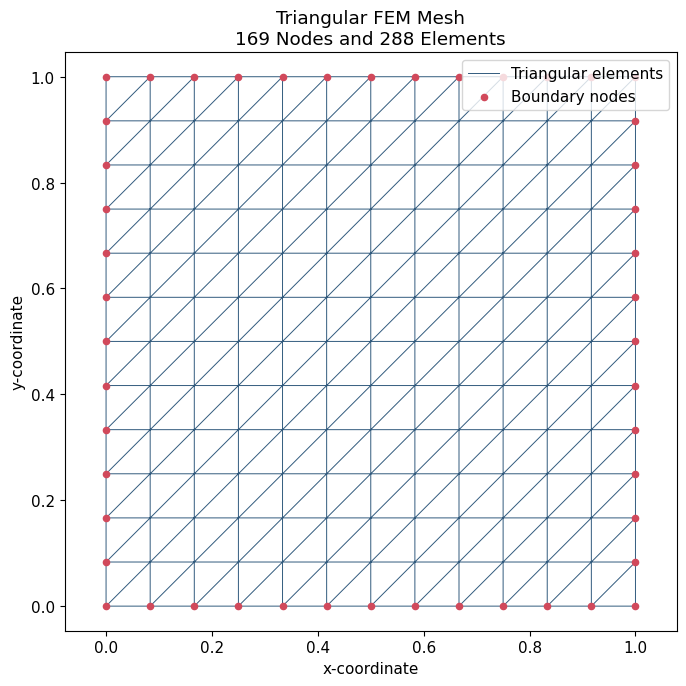

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
plt.rcParams.update({"figure.figsize": (7, 7),"font.size": 11})
print("NumPy version:", np.__version__)
Lx = 1.0
Ly = 1.0
Nx = 12
Ny = 12
x = np.linspace(0.0, Lx, Nx + 1)
y = np.linspace(0.0, Ly, Ny + 1)
X, Y = np.meshgrid(x, y, indexing="xy")
nodes = np.column_stack((X.ravel(), Y.ravel()))
hx = Lx / Nx
hy = Ly / Ny
print("Domain: [0,", Lx, "] x [0,", Ly, "]")
print("Mesh spacing in x-direction:", hx)
print("Mesh spacing in y-direction:", hy)
print("Number of nodes:", len(nodes))
print("Expected number of nodes:", (Nx + 1) * (Ny + 1))
print("\nFirst five nodes:")
print(nodes[:5])
elements = []
for j in range(Ny):
    for i in range(Nx):
        # current rectangle
        n1 = j * (Nx + 1) + i
        n2 = n1 + 1
        n3 = n1 + (Nx + 1)
        n4 = n3 + 1
        # Divide the rectangle into the triangles
        elements.append([n1, n2, n4])
        elements.append([n1, n4, n3])
elements = np.asarray(elements, dtype=int)
print("Number of triangular elements:", len(elements))
print("Expected number of elements:", 2 * Nx * Ny)
print("\nFirst five triangular elements:")
print(elements[:5])
tolerance = 1e-12
left_nodes = np.flatnonzero(np.isclose(nodes[:, 0], 0.0, atol=tolerance))
# It means: Which nodes have an x-coordinate equal, or extremely close, to 1 and then returns the positions where the answer is True
right_nodes = np.flatnonzero(np.isclose(nodes[:, 0], Lx, atol=tolerance))
bottom_nodes = np.flatnonzero(np.isclose(nodes[:, 1], 0.0, atol=tolerance))
top_nodes = np.flatnonzero(np.isclose(nodes[:, 1], Ly, atol=tolerance))
boundary_nodes = np.unique(np.concatenate([left_nodes,right_nodes,bottom_nodes,top_nodes]))
print("\nNumber of left boundary nodes:", len(left_nodes))
print("\nNumber of right boundary nodes:", len(right_nodes))
print("\nNumber of bottom boundary nodes:", len(bottom_nodes))
print("\nNumber of top boundary nodes:", len(top_nodes))
print("\nNumber of unique outer-boundary nodes:", len(boundary_nodes))
# Calculate element areas
def calculate_signed_areas(node_coordinates, connectivity):
    p1 = node_coordinates[connectivity[:, 0]]
    p2 = node_coordinates[connectivity[:, 1]]
    p3 = node_coordinates[connectivity[:, 2]]
    areas = 0.5 * ((p2[:, 0] - p1[:, 0]) *(p3[:, 1] - p1[:, 1])-(p3[:, 0] - p1[:, 0]) *(p2[:, 1] - p1[:, 1]))
    return areas
element_areas = calculate_signed_areas(nodes, elements)
assert elements.min() >= 0, "A negative node index was found."
assert elements.max() < len(nodes), "An element contains an invalid node index."
# Check that no triangular element is repeated
sorted_elements = np.sort(elements, axis=1)
unique_elements = np.unique(sorted_elements, axis=0)
assert len(unique_elements) == len(elements), "The mesh contains duplicate triangular elements."
print("Minimum element area:", element_areas.min())
print("Maximum element area:", element_areas.max())
print("Total mesh area:", element_areas.sum())
print("Exact domain area:", Lx * Ly)
expected_number_of_nodes = (Nx + 1) * (Ny + 1)
expected_number_of_elements = 2 * Nx * Ny
expected_boundary_nodes = 2 * (Nx + Ny)
assert len(nodes) == expected_number_of_nodes, "The number of nodes is incorrect."
assert len(elements) == expected_number_of_elements, "The number of elements is incorrect."
assert np.all(element_areas > 0.0), "The mesh contains reversed or degenerate triangles."
assert np.isclose(element_areas.sum(), Lx * Ly), "The total element area does not match the domain area."
assert len(boundary_nodes) == expected_boundary_nodes, "The number of boundary nodes is incorrect."
print("All mesh checks passed successfully.")
print("The triangular mesh is ready for FEM assembly.")
# Create the triangulation object
triangulation = mtri.Triangulation(nodes[:, 0],nodes[:, 1],triangles=elements)
# Plot triangular elements
plt.figure(figsize=(7, 7))
plt.triplot(triangulation,color="#315A7D",linewidth=0.7,label="Triangular elements")
# To highlight the outer-boundary nodes
plt.scatter(nodes[boundary_nodes, 0],nodes[boundary_nodes, 1],color="#D1495B",s=20,label="Boundary nodes",zorder=3)
plt.title(f"Triangular FEM Mesh\n"f"{len(nodes)} Nodes and {len(elements)} Elements")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.axis("equal")
plt.legend(loc="upper right")
plt.grid(False)
plt.tight_layout()
# Save the image
plt.savefig("triangular_fem_mesh.png",dpi=300,
    bbox_inches="tight")
plt.show()

## **Results and Analaysis**

The unit-square computational domain is discretized into triangular elements so that a linear finite element approximation can be performed.

For $N_x=N_y=12$ the mesh is made of:

- 169 nodes;
- 288 triangular elements;
- 48 unique outer boundary nodes; and
- element area total of 1.0.

All the triangular elements have positive signed areas. This establishes the order of nodes of each element in counter-clockwise direction and non-degeneracy of any element.

The sum of areas of the elements equals the exact area of the computational domain. This, along with the organized connectivity and mesh visualization, confirms the domain has been discretized correctly.

The mesh has been verified and is ready to assemble the matrices of the finite element mass and stiffness.

## **Conclusion**

In Part 1, the mathematical basis of the project of ion-transport in two dimensions was presented and a structured finite element mesh of triangular type was successfully constructed.


The domain of unit-square was discretized into 169 nodes and 288 triangular elements. The node numbers, element numbers, boundary nodes, element orientation and element areas were verified numerically. All triangles had positive signed areas and their total area was equal to the exact domain area of 1.0 . Thus, all mesh-verification checks were passed successfully.


The verified mesh is now ready for assembly of the finite element mass and stiffness matrices.
